In [1]:
# # Install all dependencies in this notebook's environment
# %pip install autobnn flowMC jax jaxlib flax matplotlib numpy tqdm scikit-learn chex optax equinox ipykernel
# !pip uninstall -y flowMC
# !pip install flowMC==0.4.4


In [2]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt

from autobnn import estimators
from autobnn import operators
from autobnn import kernels
from autobnn import likelihoods
from autobnn import training_util

seed = jax.random.PRNGKey(0)

In [3]:
# The Mauna Loa data as taken from
# https://scrippsco2.ucsd.edu/assets/data/atmospheric/stations/in_situ_co2/monthly/monthly_in_situ_co2_mlo.csv
# Data is provided by the Scripps Institution of Oceanography at UC San Diego under a CC BY license
# (https://creativecommons.org/licenses/by/4.0/).
co2_by_month = np.array('320.62,321.60,322.39,323.70,324.08,323.75,322.38,320.36,318.64,318.10,319.78,321.03,322.33,322.50,323.04,324.42,325.00,324.09,322.54,320.92,319.25,319.39,320.73,321.96,322.57,323.15,323.89,325.02,325.57,325.36,324.14,322.11,320.33,320.25,321.32,322.89,324.00,324.42,325.63,326.66,327.38,326.71,325.88,323.66,322.38,321.78,322.85,324.12,325.06,325.98,326.93,328.14,328.08,327.67,326.34,324.69,323.10,323.06,324.01,325.13,326.17,326.68,327.17,327.79,328.92,328.57,327.36,325.43,323.36,323.56,324.80,326.01,326.77,327.63,327.75,329.73,330.07,329.09,328.04,326.32,324.84,325.20,326.50,327.55,328.55,329.56,330.30,331.50,332.48,332.07,330.87,329.31,327.51,327.18,328.16,328.64,329.35,330.71,331.48,332.65,333.09,332.25,331.18,329.39,327.43,327.37,328.46,329.57,330.40,331.40,332.04,333.31,333.97,333.60,331.90,330.06,328.56,328.34,329.49,330.76,331.75,332.56,333.50,334.58,334.88,334.33,333.05,330.94,329.30,328.94,330.31,331.68,332.93,333.42,334.70,336.07,336.75,336.27,334.92,332.75,331.59,331.16,332.40,333.85,334.97,335.38,336.64,337.76,338.01,337.89,336.54,334.68,332.76,332.55,333.92,334.95,336.23,336.76,337.96,338.88,339.47,339.29,337.73,336.09,333.92,333.86,335.29,336.73,338.01,338.36,340.07,340.77,341.47,341.17,339.56,337.60,335.88,336.02,337.10,338.21,339.24,340.48,341.38,342.51,342.91,342.25,340.49,338.43,336.69,336.86,338.36,339.61,340.75,341.61,342.70,343.57,344.14,343.35,342.06,339.81,337.98,337.86,339.26,340.49,341.38,342.52,343.10,344.94,345.76,345.32,343.98,342.38,339.87,339.99,341.15,342.99,343.70,344.50,345.28,347.06,347.43,346.80,345.39,343.28,341.07,341.35,342.98,344.22,344.97,345.99,347.42,348.35,348.93,348.25,346.56,344.67,343.09,342.80,344.24,345.56,346.30,346.95,347.85,349.55,350.21,349.55,347.94,345.90,344.85,344.17,345.66,346.90,348.02,348.48,349.42,350.99,351.85,351.26,349.51,348.10,346.45,346.36,347.81,348.96,350.43,351.73,352.22,353.59,354.22,353.79,352.38,350.43,348.73,348.88,350.07,351.34,352.76,353.07,353.68,355.42,355.67,355.12,353.90,351.67,349.80,349.99,351.30,352.52,353.66,354.70,355.38,356.20,357.16,356.23,354.81,352.91,350.96,351.18,352.83,354.21,354.72,355.75,357.16,358.60,359.34,358.24,356.17,354.02,352.15,352.21,353.75,354.99,355.99,356.72,357.81,359.15,359.66,359.25,357.02,355.00,353.01,353.31,354.16,355.40,356.70,357.17,358.38,359.46,360.28,359.60,357.57,355.52,353.69,353.99,355.34,356.80,358.37,358.91,359.97,361.26,361.69,360.94,359.55,357.48,355.84,356.00,357.58,359.04,359.97,361.00,361.64,363.45,363.80,363.26,361.89,359.45,358.05,357.75,359.56,360.70,362.05,363.24,364.02,364.71,365.41,364.97,363.65,361.48,359.45,359.61,360.76,362.33,363.18,363.99,364.56,366.36,366.80,365.63,364.47,362.50,360.19,360.78,362.43,364.28,365.33,366.15,367.31,368.61,369.30,368.88,367.64,365.78,363.90,364.23,365.46,366.97,368.15,368.87,369.59,371.14,371.00,370.35,369.27,366.93,364.64,365.13,366.68,368.00,369.14,369.46,370.51,371.66,371.83,371.69,370.12,368.12,366.62,366.73,368.29,369.53,370.28,371.50,372.12,372.86,374.02,373.31,371.62,369.55,367.96,368.09,369.68,371.24,372.44,373.08,373.52,374.85,375.55,375.40,374.02,371.48,370.70,370.25,372.08,373.78,374.68,375.62,376.11,377.65,378.35,378.13,376.61,374.48,372.98,373.00,374.35,375.69,376.79,377.36,378.39,380.50,380.62,379.55,377.76,375.83,374.05,374.22,375.84,377.44,378.34,379.61,380.08,382.05,382.24,382.08,380.67,378.67,376.42,376.80,378.31,379.96,381.37,382.02,382.56,384.37,384.92,384.03,382.28,380.48,378.81,379.06,380.14,381.66,382.58,383.71,384.34,386.23,386.41,385.87,384.45,381.84,380.86,380.86,382.36,383.61,385.07,385.84,385.83,386.77,388.51,388.05,386.25,384.08,383.09,382.78,384.01,385.11,386.65,387.12,388.52,389.57,390.16,389.62,388.07,386.08,384.65,384.33,386.05,387.49,388.55,390.07,391.01,392.38,393.22,392.24,390.33,388.52,386.84,387.16,388.67,389.81,391.30,391.92,392.45,393.37,394.28,393.69,392.59,390.21,389.00,388.93,390.24,391.80,393.07,393.35,394.36,396.43,396.87,395.88,394.52,392.54,391.13,391.01,392.95,394.34,395.61,396.85,397.26,398.35,399.98,398.87,397.37,395.41,393.39,393.70,395.19,396.82,397.92,398.10,399.47,401.33,401.88,401.31,399.07,397.21,395.40,395.65,397.23,398.79,399.85,400.31,401.51,403.45,404.10,402.88,401.61,399.00,397.50,398.28,400.24,401.89,402.65,404.16,404.85,407.57,407.66,407.00,404.50,402.24,401.01,401.50,403.64,404.55,406.07,406.64,407.06,408.95,409.91,409.12,407.20,405.24,403.27,403.64,405.17,406.75,408.05,408.34,409.25,410.30,411.30,410.88,408.90,407.10,405.59,405.99,408.12,409.23,410.92'.split(',')).astype(np.float32)
num_forecast_steps = 12 * 10 # Forecast the final ten years, given previous data
co2_by_month_training_data = co2_by_month[:-num_forecast_steps]

co2_dates = np.arange("1966-01", "2019-02", dtype="datetime64[M]")

Text(0, 0.5, 'CO2 concentration / ppm')

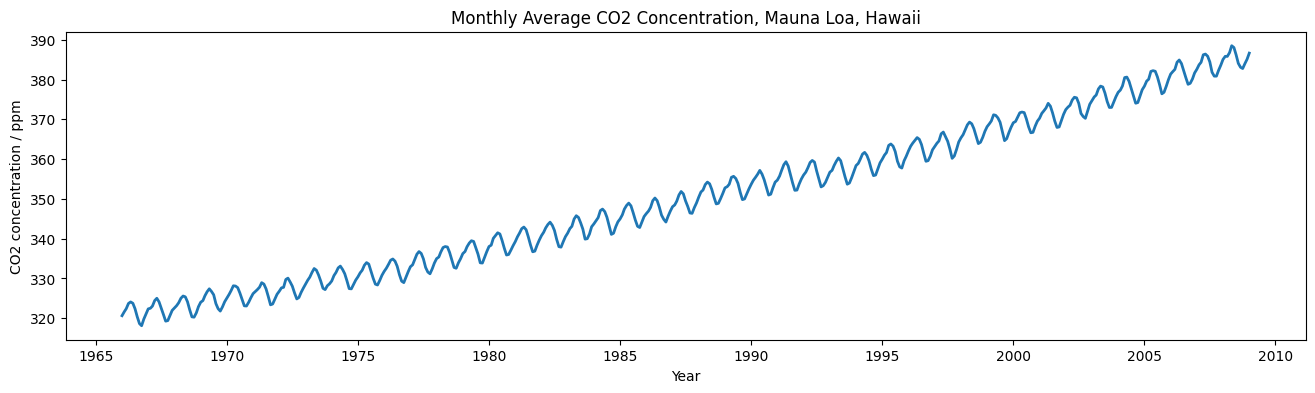

In [4]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(co2_dates[:-num_forecast_steps], co2_by_month_training_data, lw=2)
plt.title("Monthly Average CO2 Concentration, Mauna Loa, Hawaii")
plt.xlabel("Year")
plt.ylabel("CO2 concentration / ppm")

In [5]:
x_test = np.arange(len(co2_by_month), dtype=np.float32)
y_test = co2_by_month
x_train = x_test[:-num_forecast_steps]
y_train = co2_by_month_training_data

x_scale = x_train.max()
x_train = x_train / x_scale
x_test = x_test / x_scale

one_year = jnp.array(12. / x_scale, dtype=jnp.float32)  # monthly data

In [6]:
smooth_trend = kernels.ExponentiatedQuadraticBNN(
    amplitude_scale=4., length_scale_scale=one_year * 4.)

# For annoying technical reasons, any kernels used in a Multiply operator
# must pass the going_to_be_multiplied=True option in their constructor.
# (This is because the Multiply operator doesn't use the final layer of
# weights from its input BNNs, and going_to_be_multiplied=True tells the
# BNN not to create them so that they are not allocated or optimized over.)
seasonal = operators.Multiply(bnns=[
    kernels.PeriodicBNN(period=one_year, going_to_be_multiplied=True),
    kernels.ExponentiatedQuadraticBNN(amplitude_scale=4.,
                                      length_scale_scale=one_year,
                                      going_to_be_multiplied=True)])

medium_term = kernels.ExponentiatedQuadraticBNN(length_scale_scale=one_year)

# To train a BNN, we must define a likelihood model that says how likely
# the observed data is given the BNN's predictions.  The
# NormalLikelihoodLogisticNoise likelihood model says that
# P(data | predictions) ~ N(mean=predictions, scale=n)
# with
# n ~ Logistic(location=0, scale=log_noise_scale)
likelihood = likelihoods.NormalLikelihoodLogisticNoise(log_noise_scale=0.1)

kernel = operators.WeightedSum(likelihood_model=likelihood,
                               bnns=[smooth_trend, medium_term, seasonal])

In [ ]:
%%time
seed = jax.random.PRNGKey(0)
fit_seed, pred_seed, seed = jax.random.split(seed, 3)

params, loss = training_util.fit_bnn_map(
    kernel,
    seed=fit_seed,
    x_train=x_train[..., None],
    y_train=y_train[..., None],
    num_particles=32,
    # optimizer_kwargs:
    num_iters=2_000,
    learning_rate=0.01
    )

In [ ]:
preds = jax.vmap(lambda p: kernel.apply(p, x_test[..., None]))(params)

draws = likelihood.sample(params['params'], preds.squeeze(), seed=pred_seed, sample_shape=100)
lo, mid, p90, hi = jnp.percentile(draws.squeeze(), jnp.array([2.5, 50., 90., 97.5]), axis=(0, 1))

plot = training_util.plot_results(co2_dates,
                               preds,
                               dates_test=co2_dates[-num_forecast_steps:],
                               y_test=co2_by_month[-num_forecast_steps:],
                               p2_5=lo,
                               p50=mid,
                               p97_5=hi,
                               dates_train=co2_dates[:-num_forecast_steps],
                               y_train=co2_by_month[:-num_forecast_steps],
                               diagnostics=loss,
                               log_scale=True,
                               show_particles=True,
                               left_limit=50*12,
                               right_limit=10*12)

plot.axes[1].set_xlabel("Year")
plot.axes[1].set_ylabel("CO2 concentration / ppm")

In [ ]:
training_util.make_results_dataframe(mid[-num_forecast_steps:],
                                     y_test=co2_by_month[-num_forecast_steps:],
                                     y_train=co2_by_month[:-num_forecast_steps],
                                     p2_5=lo[-num_forecast_steps:],
                                     p90=p90[-num_forecast_steps:],
                                     p97_5=hi[-num_forecast_steps:]
                                     ).iloc[60]

In [ ]:
%%time
fit_seed, pred_seed, seed = jax.random.split(seed, 3)

est = estimators.AutoBnnMapEstimator(
    'sum_of_products',
    likelihood_model='normal_likelihood_logistic_noise',
    seed=jax.random.PRNGKey(0),
    periods=(one_year,),
    num_particles=32,
)

est = est.fit(x_train[..., None], y_train[..., None])

In [ ]:

preds = est.predict(x_test[..., None])
lo, mid, p90, hi = est.predict_quantiles(x_test[..., None], q=[2.5, 50., 90., 97.5])
_ = training_util.plot_results(co2_dates,
                               preds,
                               dates_test=co2_dates[-num_forecast_steps:],
                               y_test=co2_by_month[-num_forecast_steps:],
                               p2_5=lo,
                               p50=mid,
                               p97_5=hi,
                               dates_train=co2_dates[:-num_forecast_steps],
                               y_train=co2_by_month[:-num_forecast_steps],
                               diagnostics=loss,
                               log_scale=True,
                               show_particles=True,
                               left_limit=50*12,
                               right_limit=10*12)
plot.axes[1].set_xlabel("Year")
plot.axes[1].set_ylabel("CO2 concentration / ppm")

In [ ]:
training_util.make_results_dataframe(mid[-num_forecast_steps:],
                                     y_test=co2_by_month[-num_forecast_steps:],
                                     y_train=co2_by_month[:-num_forecast_steps],
                                     p2_5=lo[-num_forecast_steps:],
                                     p90=p90[-num_forecast_steps:],
                                     p97_5=hi[-num_forecast_steps:]
                                     ).iloc[60]

# USGS San Lorenzo

In [8]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import dataretrieval.nwis as nwis

# Constants
CFSToCMS_CONVERSION_FACTOR = 0.0283168466

# Site code and time range
site_code = '11160500'
start_usgs = '1979-01-01'
end_usgs = datetime.today().strftime('%Y-%m-%d')

# Download daily discharge data
df = nwis.get_record(
    sites=site_code,
    service='dv',
    parameterCd='00060',
    statCd='00003',
    start=start_usgs,
    end=end_usgs
)

# Parse datetime and set as index
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Convert cfs to cms
df['discharge_cms'] = df['00060_Mean'].astype(float) * CFSToCMS_CONVERSION_FACTOR

# Log-transform to stabilize variance (optional, often useful)
df['log_discharge_cms'] = np.log(df['discharge_cms'] + 1)


/home/jaguir26/autobnn_env/lib64/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [9]:
# Aggregate to monthly means
monthly_df = df['log_discharge_cms'].resample('ME').mean()
monthly_dates = monthly_df.index.to_numpy()
monthly_vals = monthly_df.values

print(f"Number of months: {len(monthly_vals)}, Range: {monthly_dates[0]} to {monthly_dates[-1]}")


Number of months: 557, Range: 1979-01-31 00:00:00+00:00 to 2025-05-31 00:00:00+00:00


In [ ]:
# import jax
# import jax.numpy as jnp
# import numpy as np
# import matplotlib.pyplot as plt
# from autobnn import estimators, training_util

# # Suppose your monthly data is in monthly_df (pandas Series), indexed by Timestamp
# monthly_df = df['log_discharge_cms'].resample('ME').mean()

# # Drop NaN (if any months are missing)
# monthly_df = monthly_df.dropna()

# # Define forecasting window (last 60 months)
# num_forecast_steps = 60

# y_all = monthly_df.values
# dates_all = monthly_df.index

# y_train = y_all[:-num_forecast_steps]
# y_test = y_all[-num_forecast_steps:]
# dates_train = dates_all[:-num_forecast_steps]
# dates_test = dates_all[-num_forecast_steps:]

# # AutoBNN expects normalized float arrays
# x_all = np.arange(len(y_all), dtype=np.float32)
# x_train = x_all[:-num_forecast_steps]
# x_test = x_all[-num_forecast_steps:]

# x_scale = x_train.max()  # To normalize time input
# x_train = x_train / x_scale
# x_test = x_test / x_scale


In [ ]:
# one_year = jnp.array(12. / x_scale, dtype=jnp.float32)  # Monthly data

# seed = jax.random.PRNGKey(0)
# fit_seed, pred_seed, seed = jax.random.split(seed, 3)

# est = estimators.AutoBnnMapEstimator(
#     'sum_of_products',  # automatic structure discovery!
#     likelihood_model='normal_likelihood_logistic_noise',
#     seed=fit_seed,
#     periods=(one_year,),
#     num_particles=32,
# )

# est = est.fit(x_train[..., None], y_train[..., None])


In [ ]:
# # Predict over the whole range (train + test) for visualization
# x_all_norm = np.arange(len(y_all), dtype=np.float32) / x_scale
# preds = est.predict(x_all_norm[..., None])
# lo, mid, p90, hi = est.predict_quantiles(x_all_norm[..., None], q=[2.5, 50., 90., 97.5])


In [ ]:
# import pandas as pd

# fig, ax = plt.subplots(figsize=(16, 5))
# # Plot all data
# ax.plot(dates_all, y_all, color='gray', label='Observed')
# # Plot mean prediction
# ax.plot(dates_all, mid, color='blue', label='AutoBNN median')
# # Plot uncertainty
# ax.fill_between(dates_all, lo, hi, color='blue', alpha=0.2, label='95% CI')

# # Highlight train/test split
# ax.axvline(dates_train[-1], color='black', linestyle='--', label='Train/Test Split')

# ax.set_title('San Lorenzo River @ Big Trees — Monthly log Streamflow (AutoBNN)')
# ax.set_xlabel('Year')
# ax.set_ylabel('log(discharge cms + 1)')
# ax.legend()
# plt.tight_layout()
# plt.show()


In [ ]:
# from autobnn import training_util

# # Only for the forecast period
# metrics = training_util.make_results_dataframe(
#     mid[-num_forecast_steps:],
#     y_test=y_test,
#     y_train=y_train,
#     p2_5=lo[-num_forecast_steps:],
#     p90=p90[-num_forecast_steps:],
#     p97_5=hi[-num_forecast_steps:]
# )
# display(metrics)


# Auto

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from autobnn import estimators, training_util

# Monthly log-discharge data already computed as:
monthly_df = df['log_discharge_cms'].resample('ME').mean().dropna()

# Train until Dec 2022, forecast Jan-Dec 2023
train_end = '2022-12-31'
forecast_months = 12

train_df = monthly_df[:train_end]
test_df = monthly_df[train_end:].iloc[:forecast_months]

# Setup training and test arrays
y_train = train_df.values
y_test = test_df.values

dates_train = train_df.index
dates_test = test_df.index

# Normalize x (time)
x_all = np.arange(len(monthly_df))
x_train = x_all[:len(train_df)]
x_test = x_all[len(train_df):len(train_df)+forecast_months]

x_scale = x_train.max()
x_train = x_train / x_scale
x_test = x_test / x_scale



In [ ]:
one_year = jnp.array(12. / x_scale, dtype=jnp.float32)

seed = jax.random.PRNGKey(0)
fit_seed, pred_seed, seed = jax.random.split(seed, 3)

est = estimators.AutoBnnMapEstimator(
    model_or_name='sum_of_shallow',
    likelihood_model='bounded_normal_likelihood_logistic_noise',
    seed=fit_seed,
    periods=(one_year, one_year/2, one_year/3, one_year/4, one_year*2, one_year*6.8),
    num_particles=32,  # significantly more particles
    width=100,  # significantly increased width
    num_iters=5000,  # more training iterations for better convergence
    learning_rate=0.001  # smaller learning rate for more stable training
)

est = est.fit(x_train[..., None], y_train[..., None])


2025-05-17 10:10:30.459334: E external/xla/xla/service/slow_operation_alarm.cc:73] 
********************************
[Compiling module jit__init] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2025-05-17 10:57:31.225680: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 49m0.766642398s

********************************
[Compiling module jit__init] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


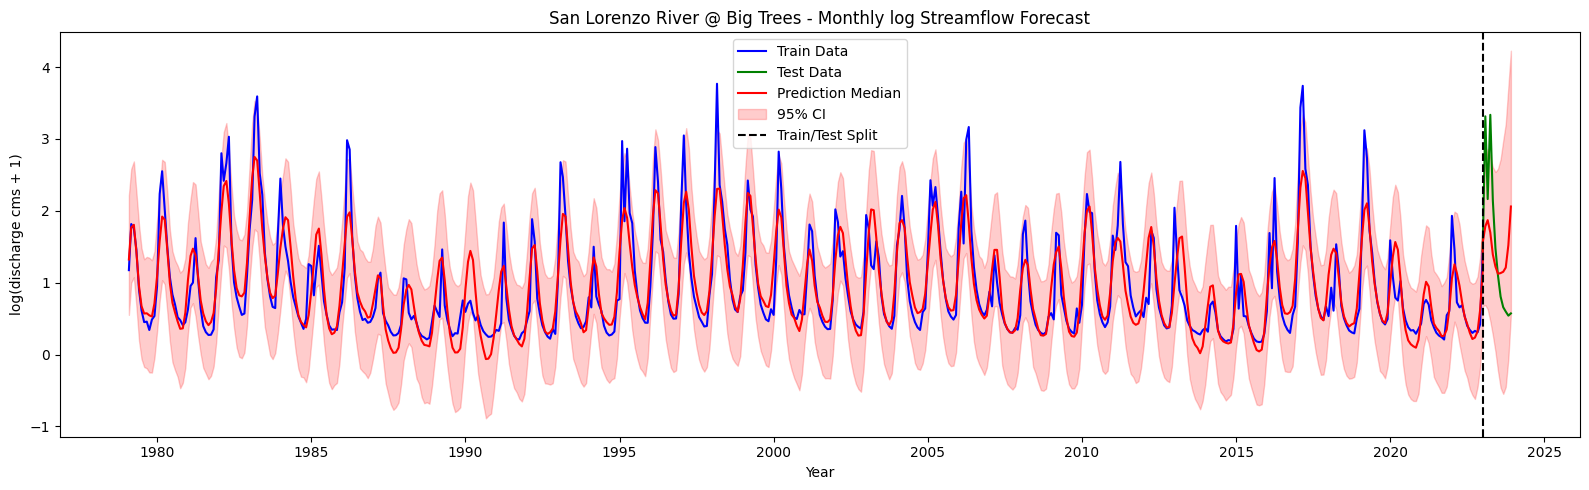

In [ ]:
# Predictions on both train and test sets
x_pred = np.concatenate([x_train, x_test])

preds = est.predict(x_pred[..., None])
lo, mid, p90, hi = est.predict_quantiles(x_pred[..., None], q=[2.5, 50., 90., 97.5])

# Plot
fig, ax = plt.subplots(figsize=(16, 5))

# Observed data
ax.plot(dates_train, y_train, label='Train Data', color='blue')
ax.plot(dates_test, y_test, label='Test Data', color='green')

# Predictions with uncertainty
dates_all = dates_train.append(dates_test)
ax.plot(dates_all, mid, color='red', label='Prediction Median')
ax.fill_between(dates_all, lo, hi, color='red', alpha=0.2, label='95% CI')

ax.axvline(dates_train[-1], color='black', linestyle='--', label='Train/Test Split')

ax.set_title('San Lorenzo River @ Big Trees - Monthly log Streamflow Forecast')
ax.set_xlabel('Year')
ax.set_ylabel('log(discharge cms + 1)')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
metrics = training_util.make_results_dataframe(
    mid[-forecast_months:],
    y_test=y_test,
    y_train=y_train,
    p2_5=lo[-forecast_months:],
    p90=p90[-forecast_months:],
    p97_5=hi[-forecast_months:]
)
display(metrics)


,yhat,yhat_lower,p90,yhat_upper,y,smape,mase,msis
0,1.554832,0.675363,2.077194,2.331864,1.438033,7.805194,0.263407,3.735748
1,1.784487,0.688199,2.388177,2.659135,3.315110,33.917187,1.857637,33.677471
2,1.870043,0.631348,2.538739,2.863245,2.163574,27.462865,1.459082,24.129446
3,1.698733,0.464660,2.414528,2.748738,3.336053,36.857222,2.017434,32.630001
4,1.391495,0.270897,2.238859,2.608052,2.143852,37.998184,1.953292,27.158155
5,1.223509,0.039403,2.144632,2.539754,1.478770,34.813864,1.723687,23.571594
6,1.124211,-0.228688,2.081469,2.585027,1.099771,30.154442,1.485320,21.110727
7,1.133831,-0.460594,2.099278,2.717310,0.806432,30.603632,1.391949,19.367737
8,1.152132,-0.546661,2.172397,2.975376,0.658511,33.261497,1.360979,18.098314
9,1.210196,-0.450195,2.425669,3.209309,0.597987,36.706888,1.362947,17.113775


In [2]:
# After you create discharge_cms and log_discharge_cms
print(f"Checking for NaNs and negatives...")

print("discharge_cms: NaNs =", df['discharge_cms'].isna().sum(), 
      "; Negatives =", (df['discharge_cms'] < 0).sum(),
      "; Zeros =", (df['discharge_cms'] == 0).sum())

print("log_discharge_cms: NaNs =", df['log_discharge_cms'].isna().sum())

# Optional: Print offending rows if any
if df['discharge_cms'].isna().any() or (df['discharge_cms'] < 0).any():
    print("Rows with missing or negative discharge_cms:")
    print(df[df['discharge_cms'].isna() | (df['discharge_cms'] < 0)])
if df['log_discharge_cms'].isna().any():
    print("Rows with NaN log_discharge_cms:")
    print(df[df['log_discharge_cms'].isna()])


Checking for NaNs and negatives...
discharge_cms: NaNs = 0 ; Negatives = 1 ; Zeros = 0
log_discharge_cms: NaNs = 1
Rows with missing or negative discharge_cms:
                            site_no  00060_Mean 00060_Mean_cd  discharge_cms  \
datetime                                                                       
2025-05-13 00:00:00+00:00  11160500   -999999.0        P, Eqp  -28316.818283   

                           log_discharge_cms  
datetime                                      
2025-05-13 00:00:00+00:00                NaN  
Rows with NaN log_discharge_cms:
                            site_no  00060_Mean 00060_Mean_cd  discharge_cms  \
datetime                                                                       
2025-05-13 00:00:00+00:00  11160500   -999999.0        P, Eqp  -28316.818283   

                           log_discharge_cms  
datetime                                      
2025-05-13 00:00:00+00:00                NaN  


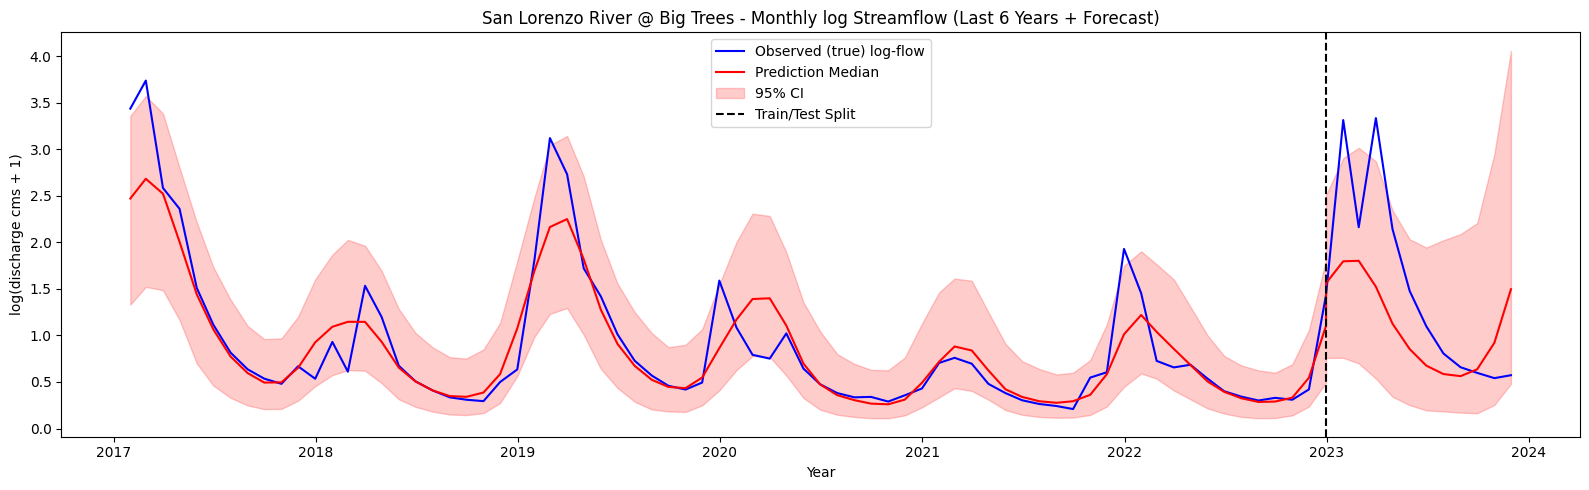

In [1]:
#!/usr/bin/env python3

# Plot AutoBNN forecast: Last 6 years + forecast period

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from datetime import datetime

# ========== PARAMETERS ==========
MODEL_FILE = "san_lorenzo_autobnn_estimator.pkl"
DATA_FILE = None  # Optionally, save/load your monthly_df as .csv to avoid recomputation
TRAIN_END = '2022-12-31'
FORECAST_MONTHS = 12
PLOT_YEARS = 6  # How many years to show

# ========== 1. LOAD MONTHLY DATA (rerun your pipeline or load CSV) ==========

CFSToCMS_CONVERSION_FACTOR = 0.0283168466
SITE_CODE = '11160500'
START_USGS = '1979-01-01'
END_USGS = datetime.today().strftime('%Y-%m-%d')

import dataretrieval.nwis as nwis

# Download and preprocess data
df = nwis.get_record(
    sites=SITE_CODE,
    service='dv',
    parameterCd='00060',
    statCd='00003',
    start=START_USGS,
    end=END_USGS
)
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df['discharge_cms'] = df['00060_Mean'].astype(float) * CFSToCMS_CONVERSION_FACTOR
df_clean = df[
    (df['discharge_cms'].notna()) &
    (df['discharge_cms'] >= 0) &
    (df['00060_Mean'] != -999999.0)
].copy()
df_clean['log_discharge_cms'] = np.log(df_clean['discharge_cms'] + 1)
monthly_df = df_clean['log_discharge_cms'].resample('ME').mean().dropna()

# Train/test split
train_df = monthly_df[:TRAIN_END]
test_df = monthly_df[TRAIN_END:].iloc[:FORECAST_MONTHS]

y_train = train_df.values
y_test = test_df.values
dates_train = train_df.index
dates_test = test_df.index

# Normalize time indices (repeat exactly as in original fit)
x_all = np.arange(len(monthly_df))
x_train = x_all[:len(train_df)]
x_test = x_all[len(train_df):len(train_df) + FORECAST_MONTHS]
x_scale = x_train.max()
x_train = x_train / x_scale
x_test = x_test / x_scale

x_pred = np.concatenate([x_train, x_test])
dates_all = dates_train.append(dates_test)

# ========== 2. LOAD FITTED ESTIMATOR ==========
with open(MODEL_FILE, "rb") as f:
    est = pickle.load(f)

# ========== 3. MAKE PREDICTIONS ==========
preds = est.predict(x_pred[..., None])
lo, mid, p90, hi = est.predict_quantiles(x_pred[..., None], q=[2.5, 50., 90., 97.5])

# ========== 4. SELECT LAST 6 YEARS + FORECAST PERIOD ==========
# Last 6 years (72 months) of training + forecast (12 months)
months_to_plot = 6 * 12 + FORECAST_MONTHS
x_plot = -months_to_plot

dates_all_plot = dates_all[x_plot:]
y_all_plot = np.concatenate([y_train, y_test])[x_plot:]
mid_plot = mid[x_plot:]
lo_plot = lo[x_plot:]
hi_plot = hi[x_plot:]

# ========== 5. PLOT ==========

plt.figure(figsize=(16, 5))
plt.plot(dates_all_plot, y_all_plot, label='Observed (true) log-flow', color='blue')
plt.plot(dates_all_plot, mid_plot, color='red', label='Prediction Median')
plt.fill_between(dates_all_plot, lo_plot, hi_plot, color='red', alpha=0.2, label='95% CI')
plt.axvline(dates_train[-1], color='black', linestyle='--', label='Train/Test Split')
plt.title('San Lorenzo River @ Big Trees - Monthly log Streamflow (Last 6 Years + Forecast)')
plt.xlabel('Year')
plt.ylabel('log(discharge cms + 1)')
plt.legend()
plt.tight_layout()
plt.savefig("san_lorenzo_autobnn_forecast_last6years.png", dpi=300)
plt.show()
